# Titanic Survival - Statistical Analysis

Dataset: [Kaggle Titanic dataset](https://www.kaggle.com/c/titanic/data), public data used for this assignment.

**Contents**

1. Load and Inspect
2. Univariate Analysis
3. Outlier Detection
4. Missingness Mechanism
5. Feature Engineering
6. Bivariate Analysis
7. Hypothesis Testing
8. Summary

**Statistical tests performed**

- Chi-square test of independence: Age missingness vs Pclass, and vs Survived
- Chi-square test of independence + Cramer's V: Sex, Pclass, Embarked vs Survived
- Levene's test: equal variance check for Fare
- Welch's t-test: Fare, survived vs not survived
- Cohen's d: effect size for the t-test
- Shapiro-Wilk test: normality check for Fare
- Mann-Whitney U test: non-parametric check for Fare
- One-way ANOVA: Fare across Pclass
- Bonferroni correction: applied across all significance tests

## 1. Load and Inspect

- Load the dataset
- Check shape, data types, summary stats, missing values

In [1]:
import pandas as pd 

#Load the dataset 
df=pd.read_csv("../data/train.csv")

#Quick Sanity Check
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns") #Shape

Dataset shape: 891 rows, 12 columns


In [3]:
# Structural info

df.info()  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Observations from describe():

- **Age**: mean ~30, max 80, check for outliers later
- **Fare**: min ~0, max ~512, likely right-skewed
- **SibSp, Parch**: mostly 0, most passengers traveled alone

In [5]:
# Missing values in ascending order

df.isnull().sum().sort_values(ascending=False)

Cabin          687
Age            177
Embarked         2
PassengerId      0
Name             0
Pclass           0
Survived         0
Sex              0
Parch            0
SibSp            0
Fare             0
Ticket           0
dtype: int64

Missing values:

- **Cabin**: 687 missing (77%), too sparse to impute, convert to a has_cabin flag
- **Age**: 177 missing (20%), impute using median
- **Embarked**: 2 missing, impute using mode

## 2. Univariate Analysis

- Check distribution shape and skewness for numeric features
- Check value counts for categorical features

In [6]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "string"]).columns.tolist()

# PassengerId is an identifier, not a real numeric feature — exclude it from analysis
numeric_cols.remove("PassengerId")

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)

Numeric columns: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Categorical columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


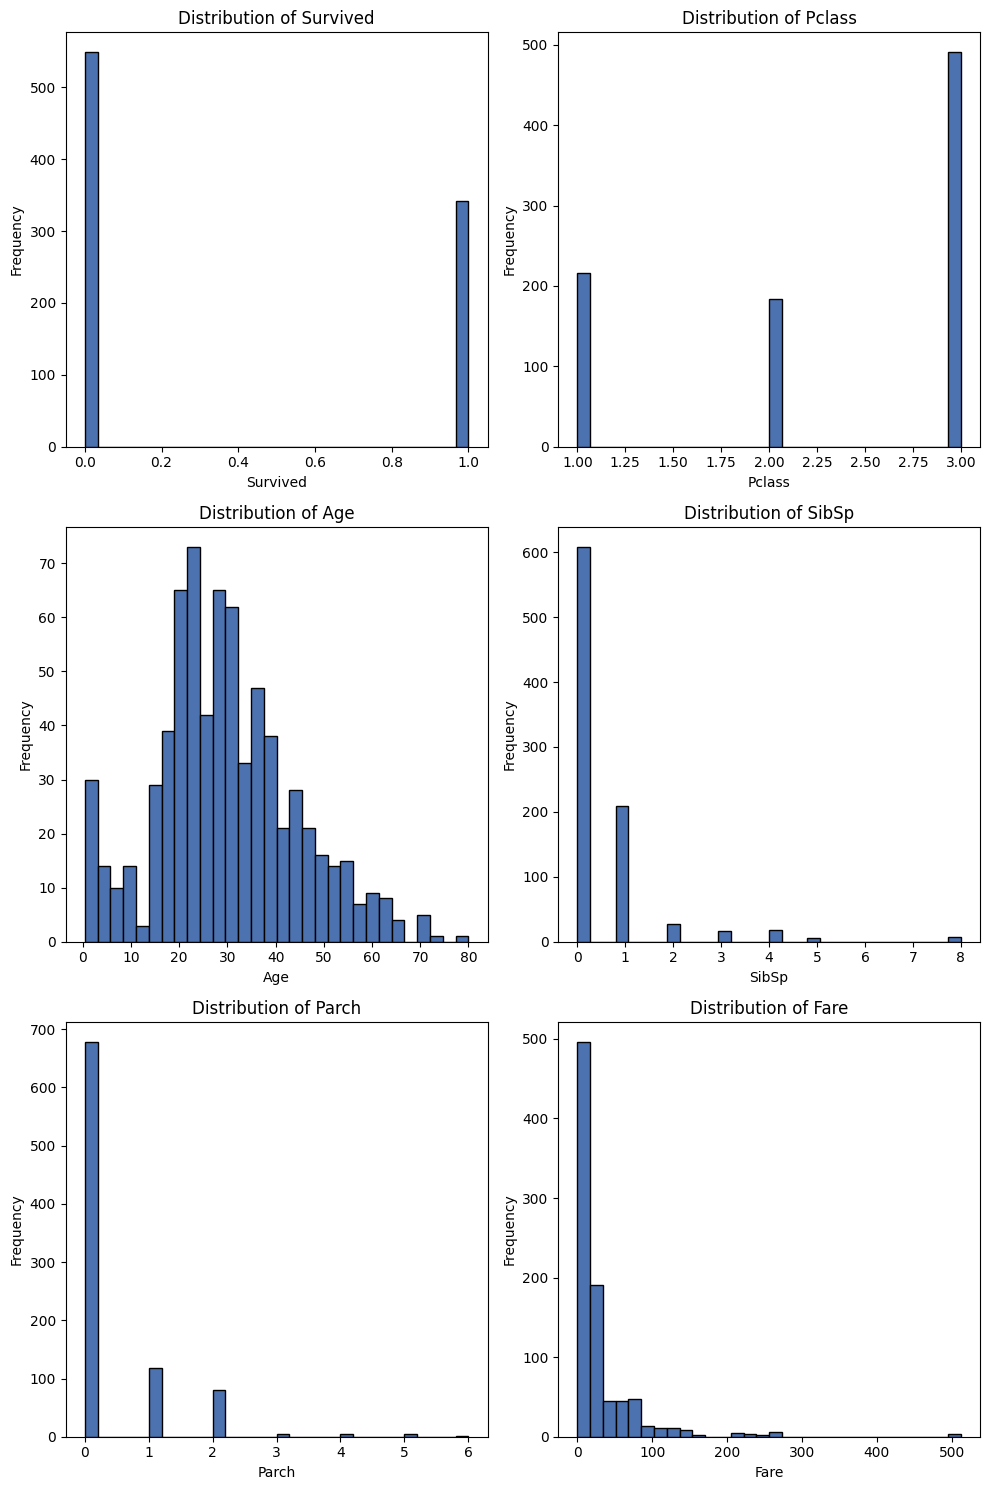

In [30]:
## Histograms for every numeric column

import matplotlib.pyplot as plt 

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10,15))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color ="#4C72B0" , edgecolor="black")
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide any unused subplots axes

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
# Skewness Calculation

skewness = df[numeric_cols].skew().sort_values(ascending=False)
print(skewness)

Fare        4.787317
SibSp       3.695352
Parch       2.749117
Survived    0.478523
Age         0.389108
Pclass     -0.630548
dtype: float64


Skewness rule of thumb: |skew| > 1 highly skewed, 0.5-1 moderate, < 0.5 symmetric.

| Column | Skewness | Decision |
|---|---|---|
| Fare | 4.79 | Log-transform (log1p) |
| SibSp | 3.70 | Bucket into 0 / 1 / 2+ |
| Parch | 2.75 | Bucket into 0 / 1 / 2+ |
| Age | 0.39 | Median imputation |

- **Age**: median used instead of mean, because the long right tail from older passengers pulls the mean up
- **Fare**: log-transform fits since it's continuous and strictly positive; SibSp/Parch are small integer counts so bucketing keeps them interpretable

In [9]:
# Value counts for catgorical columns 

for col in ["Sex", "Embarked", "Pclass"]:
    print(f"\n--------------{col}-----------")
    print(df[col].value_counts(dropna=False))


--------------Sex-----------
Sex
male      577
female    314
Name: count, dtype: int64

--------------Embarked-----------
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

--------------Pclass-----------
Pclass
3    491
1    216
2    184
Name: count, dtype: int64


Categorical observations:

- **Sex**: 65% male, 35% female
- **Pclass**: more 3rd class passengers than 1st and 2nd combined
- **Embarked**: mostly Southampton (S), 2 missing values to impute with mode

## 3. Outlier Detection

- Use boxplots to spot outliers visually
- Use the IQR rule to quantify outliers per column

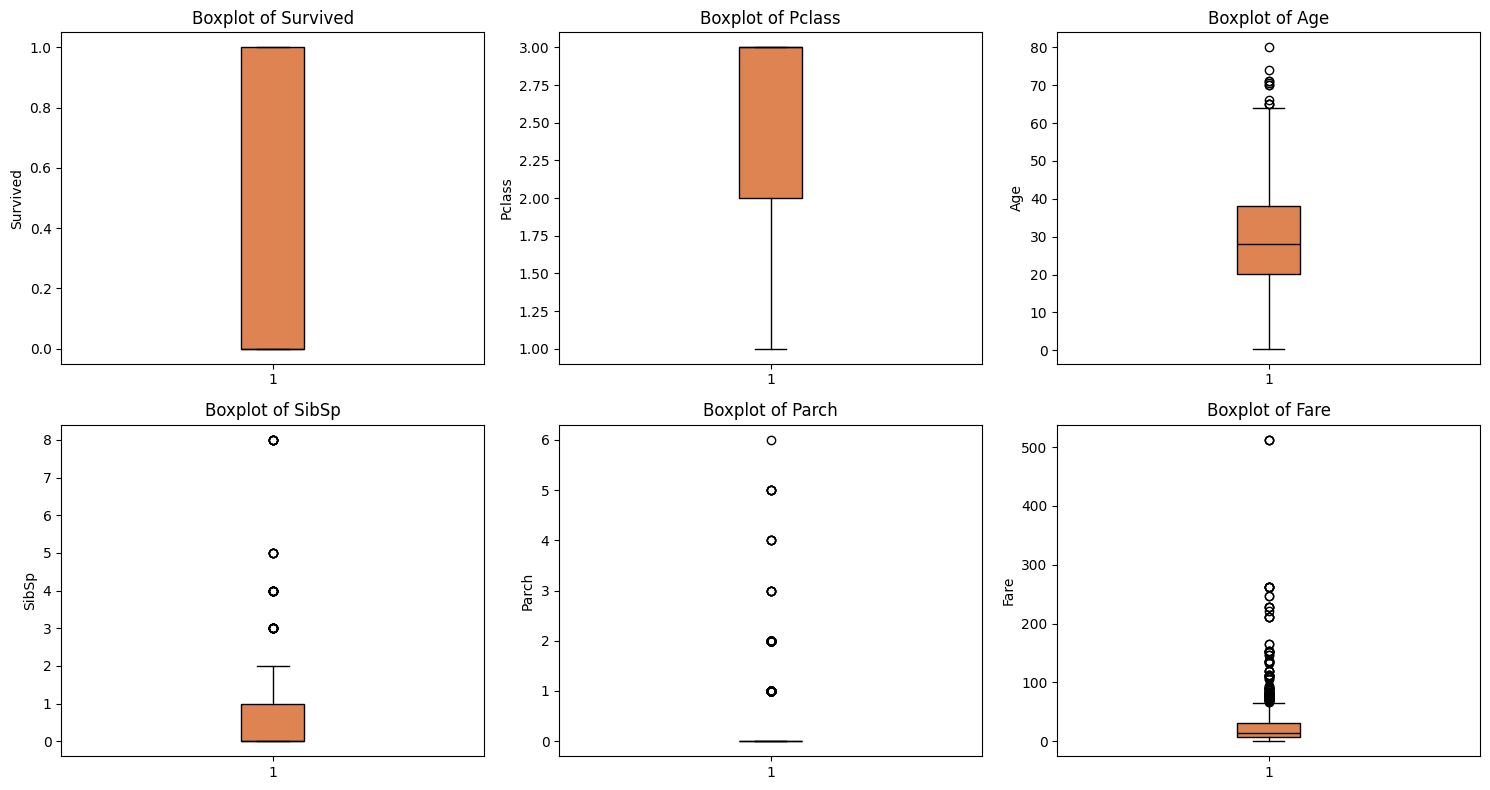

In [10]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col].dropna(), orientation="vertical", patch_artist=True,
                     boxprops=dict(facecolor="#DD8452", color="black"),
                     medianprops=dict(color="black"))
    axes[i].set_title(f"Boxplot of {col}")
    axes[i].set_ylabel(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [11]:
def count_outliers_iqr(series: pd.Series) -> dict:
    """
    Apply the IQR rule to a numeric series and return outlier counts and bounds.
    Outliers are values below Q1 - 1.5*IQR or above Q3 + 1.5*IQR.
    """
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[(series < lower_bound) | (series > upper_bound)]

    return {
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "IQR": round(iqr, 2),
        "lower_bound": round(lower_bound, 2),
        "upper_bound": round(upper_bound, 2),
        "outlier_count": outliers.shape[0],
        "outlier_pct": round(outliers.shape[0] / series.dropna().shape[0] * 100, 2),
    }


outlier_summary = pd.DataFrame({
    col: count_outliers_iqr(df[col].dropna()) for col in numeric_cols
}).T

outlier_summary

,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_pct
Survived,0.00,1.0,1.00,-1.50,2.50,0.0,0.00
Pclass,2.00,3.0,1.00,0.50,4.50,0.0,0.00
Age,20.12,38.0,17.88,-6.69,64.81,11.0,1.54
SibSp,0.00,1.0,1.00,-1.50,2.50,46.0,5.16
Parch,0.00,0.0,0.00,0.00,0.00,213.0,23.91
Fare,7.91,31.0,23.09,-26.72,65.63,116.0,13.02


Survived (binary) and Pclass (ordinal) are excluded, the IQR rule does not apply to them.

| Column | Outliers | % | Decision |
|---|---|---|---|
| Age | 11 | 1.54% | Keep, real values |
| SibSp | 46 | 5.16% | Keep, bucket instead of removing |
| Parch | 213 | 23.91% | Keep, IQR rule overreacts on sparse data (Q1=Q3=0) |
| Fare | 116 | 13.02% | Keep, log-transform instead of removing |

> Only remove outliers if they look like data errors (e.g. negative age). All flagged values here are real, so they are kept and handled with transforms or bucketing instead.

## 4. Missingness Mechanism

Check if Age is missing at random, or if it depends on other columns. This affects how it should be imputed.

In [12]:
from scipy import stats

df["Age_missing"] = df["Age"].isnull().astype(int)

pclass_test = pd.crosstab(df["Age_missing"], df["Pclass"])
chi2, p1, dof, exp = stats.chi2_contingency(pclass_test)
print(f"Age missing vs Pclass: chi2={chi2:.2f}, p={p1:.6f}")

survived_test = pd.crosstab(df["Age_missing"], df["Survived"])
chi2, p2, dof, exp = stats.chi2_contingency(survived_test)
print(f"Age missing vs Survived: chi2={chi2:.2f}, p={p2:.6f}")

Age missing vs Pclass: chi2=46.06, p=0.000000
Age missing vs Survived: chi2=7.11, p=0.007683


- **Age missing vs Pclass**: p < 0.001, significant. 3rd class passengers are far more likely to have missing age
- **Age missing vs Survived**: p = 0.008, significant at 0.05 level
- Age is not missing completely at random (MCAR), it is **Missing At Random (MAR)**, related to Pclass
- Better approach: impute Age using median per Pclass/Title group instead of one global median

## 5. Feature Engineering

Create a few extra features that are common for this dataset and useful for analysis and modeling.

In [13]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["HasCabin"] = df["Cabin"].notna().astype(int)

df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.")
rare_titles = df["Title"].value_counts()[lambda x: x < 10].index.tolist()
df["Title"] = df["Title"].replace(rare_titles, "Rare")
df["Title"] = df["Title"].replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})

print(df["Title"].value_counts())
print()
print("Median age by title:")
print(df.groupby("Title")["Age"].median())

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

Median age by title:
Title
Master     3.5
Miss      21.0
Mr        30.0
Mrs       35.0
Rare      44.5
Name: Age, dtype: float64


In [14]:
print("Survival rate by FamilySize:")
print(df.groupby("FamilySize")["Survived"].mean())
print()
print("Survival rate by IsAlone:")
print(df.groupby("IsAlone")["Survived"].mean())
print()
print("Survival rate by HasCabin:")
print(df.groupby("HasCabin")["Survived"].mean())

Survival rate by FamilySize:
FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64

Survival rate by IsAlone:
IsAlone
0    0.505650
1    0.303538
Name: Survived, dtype: float64

Survival rate by HasCabin:
HasCabin
0    0.299854
1    0.666667
Name: Survived, dtype: float64


- **FamilySize** 2-4: highest survival (55-72%). Alone or FamilySize 5+: lower survival (0-33%)
- **IsAlone**: 30% survival vs 51% for passengers with family
- **HasCabin**: 67% survival vs 30% for missing cabin (likely a proxy for class, not the cabin itself)
- **Title** gives a cleaner age estimate than one median: Master 3.5, Miss 21, Mr 30, Mrs 35, Rare 44.5

## 6. Bivariate Analysis

- Correlation heatmap for numeric features
- Survival rate by Sex, Pclass, Embarked, Age group
- Chi-square tests to confirm the categorical relationships are real
- Sex and Pclass combined, to check for interaction

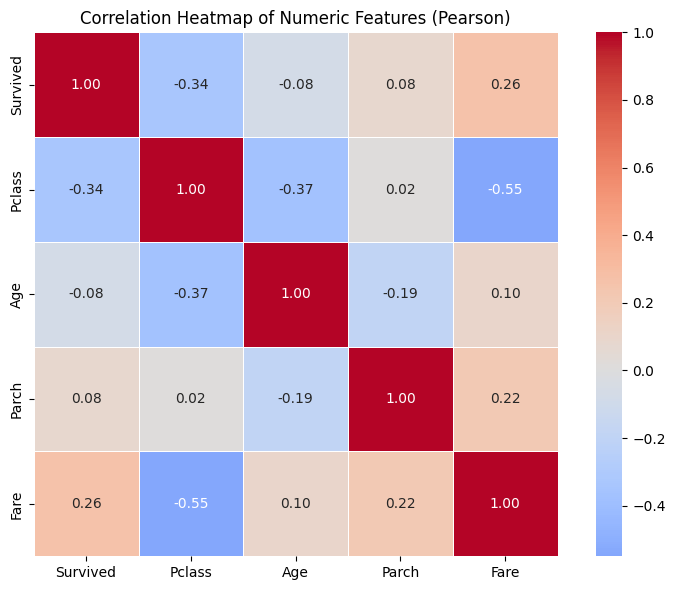

Spearman correlation (captures monotonic, not just linear, relationships):
          Survived  Pclass   Age  Parch  Fare
Survived      1.00   -0.34 -0.05   0.14  0.32
Pclass       -0.34    1.00 -0.36  -0.02 -0.69
Age          -0.05   -0.36  1.00  -0.25  0.14
Parch         0.14   -0.02 -0.25   1.00  0.41
Fare          0.32   -0.69  0.14   0.41  1.00


In [15]:
import seaborn as sns 

# Only numeric columns are meaningful for correlation 

corr_cols = ["Survived", "Pclass", "Age", "Parch", "Fare"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize = (8,6))
sns.heatmap(corr_matrix, annot = True , fmt=".2f", cmap="coolwarm", center=0, 
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features (Pearson)")
plt.tight_layout()
plt.show()

print("Spearman correlation (captures monotonic, not just linear, relationships):")
print(df[corr_cols].corr(method="spearman").round(2))

Correlation heatmap:

- **Pclass and Survived**: -0.34, higher class number means lower survival
- **Fare and Survived**: 0.26, higher fare means higher survival
- **Pclass and Fare**: -0.55, 1st class costs more
- **Age and Survived**: -0.08, weak, survival by age is not linear (see age group breakdown)
- **SibSp and Parch**: 0.41, families tend to travel together
- Spearman is close to Pearson here except **Pclass-Fare** (-0.69 vs -0.55), which makes sense since Fare is skewed and Spearman is not affected by that
- Sex and Embarked are excluded, they are unordered categories, checked separately below

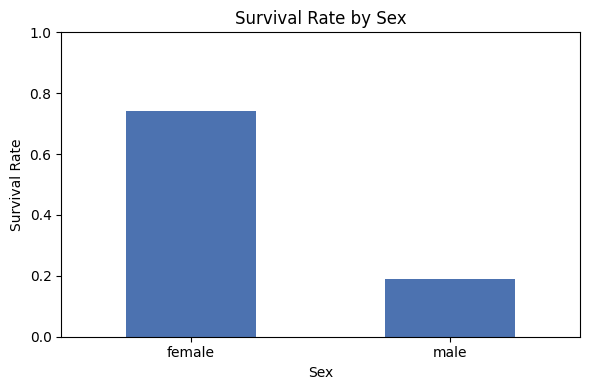

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [16]:
# Survival rate by Sex

survival_by_sex = df.groupby("Sex")["Survived"].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
survival_by_sex.plot(kind="bar", color="#4C72B0")
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(survival_by_sex)

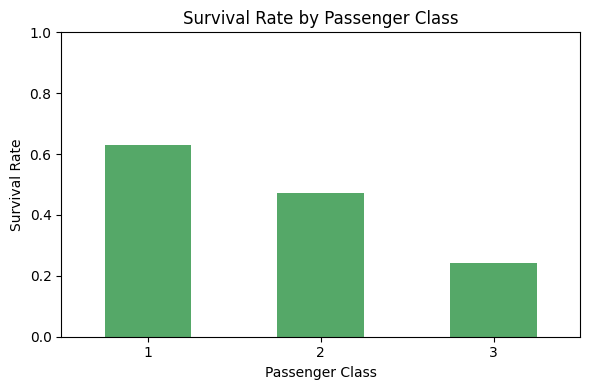

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [17]:
# Survival rate by Passenger Class

survival_by_class = df.groupby("Pclass")["Survived"].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
survival_by_class.plot(kind="bar", color="#55A868")
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(survival_by_class)

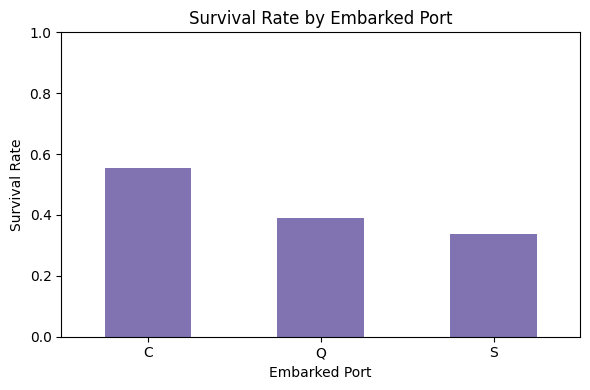

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


In [18]:
# Survival rate by Embarked port

survival_by_embarked = df.groupby("Embarked")["Survived"].mean().sort_values(ascending=False)

plt.figure(figsize=(6, 4))
survival_by_embarked.plot(kind="bar", color="#8172B2")
plt.title("Survival Rate by Embarked Port")
plt.xlabel("Embarked Port")
plt.ylabel("Survival Rate")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(survival_by_embarked)

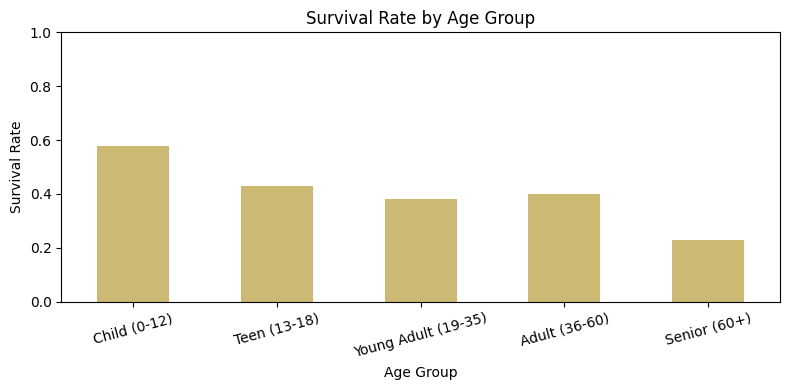

AgeGroup
Child (0-12)           0.579710
Teen (13-18)           0.428571
Young Adult (19-35)    0.382682
Adult (36-60)          0.400000
Senior (60+)           0.227273
Name: Survived, dtype: float64


In [19]:
## Survival rate by Age Group

# Create age bins - a common, interpretable binning scheme
age_bins = [0, 12, 18, 35, 60, 100]
age_labels = ["Child (0-12)", "Teen (13-18)", "Young Adult (19-35)", "Adult (36-60)", "Senior (60+)"]

df["AgeGroup"] = pd.cut(df["Age"], bins=age_bins, labels=age_labels)

survival_by_agegroup = df.groupby("AgeGroup", observed=True)["Survived"].mean()

plt.figure(figsize=(8, 4))
survival_by_agegroup.plot(kind="bar", color="#CCB974")
plt.title("Survival Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Survival Rate")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

print(survival_by_agegroup)

Survival rate breakdowns:

- **Sex**: women 74%, men 19%, the strongest single predictor
- **Pclass**: 1st 63%, 2nd 47%, 3rd 24%
- **Embarked**: Cherbourg 55%, Queenstown 39%, Southampton 34%, likely explained by class mix at each port, not the port itself
- **Age group**: children highest survival, seniors lowest

These are single-variable rates and do not account for interactions. Checked below with chi-square tests and a Sex x Pclass breakdown.

In [20]:
import numpy as np

def cramers_v(table):
    chi2 = stats.chi2_contingency(table)[0]
    n = table.sum().sum()
    r, k = table.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

for col in ["Sex", "Pclass", "Embarked"]:
    tmp = df.dropna(subset=[col])
    table = pd.crosstab(tmp[col], tmp["Survived"])
    chi2, p, dof, exp = stats.chi2_contingency(table)
    v = cramers_v(table)
    print(f"{col}: chi2={chi2:.2f}, p={p:.6f}, cramers_v={v:.2f}")

Sex: chi2=260.72, p=0.000000, cramers_v=0.54
Pclass: chi2=102.89, p=0.000000, cramers_v=0.34
Embarked: chi2=26.49, p=0.000002, cramers_v=0.17


**Chi-square tests**

Confirm all three relationships are real, not due to chance:

- **Sex**: p < 0.001, Cramer's V 0.54 (strong)
- **Pclass**: p < 0.001, Cramer's V 0.34 (moderate)
- **Embarked**: p < 0.001, Cramer's V 0.17 (weak)

Cramer's V shows how strong the relationship is, since a p-value alone does not show effect size. This matches the bar charts: Sex has by far the strongest effect.

Sex       female      male
Pclass                    
1       0.968085  0.368852
2       0.921053  0.157407
3       0.500000  0.135447


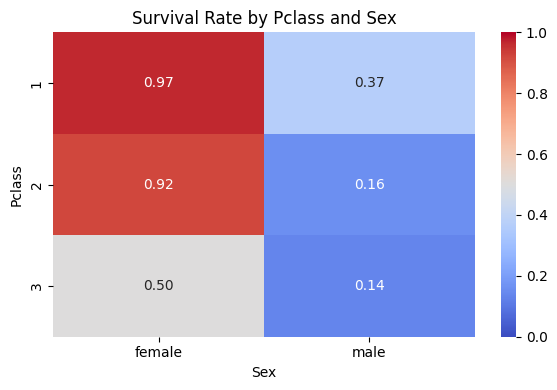

In [21]:
sex_pclass_survival = df.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()
print(sex_pclass_survival)

plt.figure(figsize=(6, 4))
sns.heatmap(sex_pclass_survival, annot=True, fmt=".2f", cmap="coolwarm", vmin=0, vmax=1)
plt.title("Survival Rate by Pclass and Sex")
plt.tight_layout()
plt.show()

**Sex x Pclass interaction**

Survival rate by class and sex:

- **1st class**: women 97%, men 37%
- **2nd class**: women 92%, men 16%
- **3rd class**: women 50%, men 14%

Class matters far more for women than for men. A 3rd class woman (50%) survived less than a 1st or 2nd class woman, but still far more than any group of men. This confirms Sex is the dominant factor, with Pclass as a secondary effect on top of it.

## 7. Hypothesis Testing

Formal significance tests to confirm the differences seen in the plots above.

**Test 1: Fare vs Survived (t-test)**

Does mean Fare differ between survivors and non-survivors?

- H0: no difference (mean fare survived = mean fare not survived)
- H1: there is a difference
- alpha = 0.05

In [22]:
## Check Assumption First 

survived_fare = df[df["Survived"]== 1]["Fare"]
not_survived_fare = df[df["Survived"]==0]["Fare"]

print(f"Survived group; n={survived_fare.shape[0]}, mean=${survived_fare.mean():.2f}, std=${survived_fare.std():.2f}")
print(f"Not survived group: n= {not_survived_fare.shape[0]}, mean =${not_survived_fare.mean():.2f}, std=${not_survived_fare.std():.2f}")

Survived group; n=342, mean=$48.40, std=$66.60
Not survived group: n= 549, mean =$22.12, std=$31.39


In [23]:
# Variance check to justify which t-test variants to use 

from scipy import stats 

# Levene's test checks whether the two groups have equal variances
levene_stats, levene_p = stats.levene(survived_fare, not_survived_fare)
print(f"Levene's test p-value: {levene_p:.5f}")


equal_var_assumption = levene_p > 0.05
print(f"Equal variances assumed: {equal_var_assumption}")


Levene's test p-value: 0.00000
Equal variances assumed: False


In [24]:
## Run the t-test using the correcyt variant 

t_stat, p_value = stats.ttest_ind(
    survived_fare,
    not_survived_fare,
    equal_var=equal_var_assumption
)
alpha = 0.05

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.6f}")
print(f"Significance level (α): {alpha}")

if p_value < alpha:
    decision = "Reject H0"
else:
    decision = "Fail to reject H0"

print(f"Decision: {decision}")

t-statistic: 6.8391
p-value: 0.000000
Significance level (α): 0.05
Decision: Reject H0


**Results**

- H0: no difference in mean fare
- Levene's test p = 0.00000, variances not equal, used Welch's t-test
- t = 6.84, p < 0.001

> Decision: reject H0

Survivors paid a higher mean fare on average. This lines up with the Pclass and Fare findings above.

In [25]:
n1, n2 = len(survived_fare), len(not_survived_fare)
pooled_std = np.sqrt(((n1 - 1) * survived_fare.std()**2 + (n2 - 1) * not_survived_fare.std()**2) / (n1 + n2 - 2))
cohens_d = (survived_fare.mean() - not_survived_fare.mean()) / pooled_std
print(f"Cohen's d = {cohens_d:.2f}")

Cohen's d = 0.55


**Effect size (Cohen's d)**

Cohen's d = 0.55, a medium effect size. The p-value shows the difference is real, the effect size shows how big it is in practical terms.

In [26]:
shapiro_stat, shapiro_p = stats.shapiro(df["Fare"].dropna().sample(500, random_state=42))
print(f"Shapiro-Wilk (sample of 500): p={shapiro_p:.6f}")

u_stat, p_mw = stats.mannwhitneyu(survived_fare, not_survived_fare, alternative="two-sided")
print(f"Mann-Whitney U test: p={p_mw:.6f}")

Shapiro-Wilk (sample of 500): p=0.000000
Mann-Whitney U test: p=0.000000


**Normality check**

- Shapiro-Wilk p < 0.001: Fare is not normally distributed, matches the skewness found in Section 2
- The t-test assumes normality, but with n=891 the central limit theorem makes it reasonably safe. Still worth checking with a test that does not assume normality
- Mann-Whitney U test (non-parametric): p < 0.001, same conclusion as the t-test
- Both tests agree, so the result is not an artifact of the skewed Fare distribution

In [27]:
groups = [df[df["Pclass"] == p]["Fare"] for p in sorted(df["Pclass"].unique())]
f_stat, p_anova = stats.f_oneway(*groups)
print(f"F = {f_stat:.2f}, p = {p_anova:.6f}")

F = 242.34, p = 0.000000


**Test 2: Fare across Pclass (ANOVA)**

F = 242.34, p < 0.001. Mean fare is significantly different across the three passenger classes, confirms what the correlation heatmap already showed (Pclass and Fare, -0.55).

In [28]:
alpha = 0.05
n_tests = 5
adjusted_alpha = alpha / n_tests
print(f"Bonferroni adjusted alpha = {adjusted_alpha:.4f}")
print("All p-values above are far smaller than this, so every result still holds after correction.")

Bonferroni adjusted alpha = 0.0100
All p-values above are far smaller than this, so every result still holds after correction.


**Multiple comparison correction**

5 significance tests were run in this notebook (Fare t-test, 3 chi-square tests, ANOVA). Running many tests raises the chance of a false positive, so the significance level should be stricter. Bonferroni adjusted alpha = 0.01. Every p-value above is far below this, so all results stay significant.

## 8. Summary

**Key findings**

- **Sex** is the strongest predictor of survival: women 74%, men 19%
- **Class and fare** tell the same story: 1st class passengers survived more and paid more, both linked to wealth and cabin location
- **Class x Sex**: class matters far more for men than for women. Women survived at 92%+ in 1st and 2nd class regardless, men's survival dropped sharply as class dropped
- **Age**: children survived more than any other age group; age alone is a weak predictor because this effect sits in one group, not a straight line
- **Embarked**: looks predictive on its own, but is mostly explained by the class mix at each port, not the port itself

**Data quality and features**

- **Age** is missing more often for 3rd class passengers, not randomly, so it should be imputed by class or title group, not one global median
- **FamilySize and HasCabin** are useful added features: mid-size families survived more than solo travelers, and HasCabin mostly reflects class rather than the cabin itself

> All key relationships (chi-square, t-test, ANOVA) stayed significant even after correcting for running multiple tests, so these findings are not due to chance.